In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

In [14]:
# 시스템에 설치된 폰트 중 한글 가능한 것 확인 및 적용
fonts = sorted({f.name for f in fm.fontManager.ttflist})
korean_candidates = ['Malgun Gothic', 'NanumGothic', 'NanumBarunGothic', 'AppleGothic']

found = next((candidate for candidate in korean_candidates if candidate in fonts), None)

if found is None:
    raise RuntimeError('사용 가능한 한글 폰트를 찾지 못했습니다. 설치된 폰트 목록을 확인하세요.')

plt.rcParams['font.family'] = found
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(font=found, rc={'axes.unicode_minus': False})

print("사용할 폰트:", found)
print()

# 전체 폰트 목록도 같이 출력 (후보가 없을 경우 직접 고르기 위해)
korean_fonts = [f for f in fonts if 'Gothic' in f or 'Nanum' in f or 'Malgun' in f]
print("한글 관련 폰트 목록:", korean_fonts)

사용할 폰트: Malgun Gothic

한글 관련 폰트 목록: ['Franklin Gothic Medium', 'MS Gothic', 'Malgun Gothic', 'NanumGothic', 'NanumMyeongjo', 'NanumSquare', 'NanumSquare_ac', 'Yu Gothic']


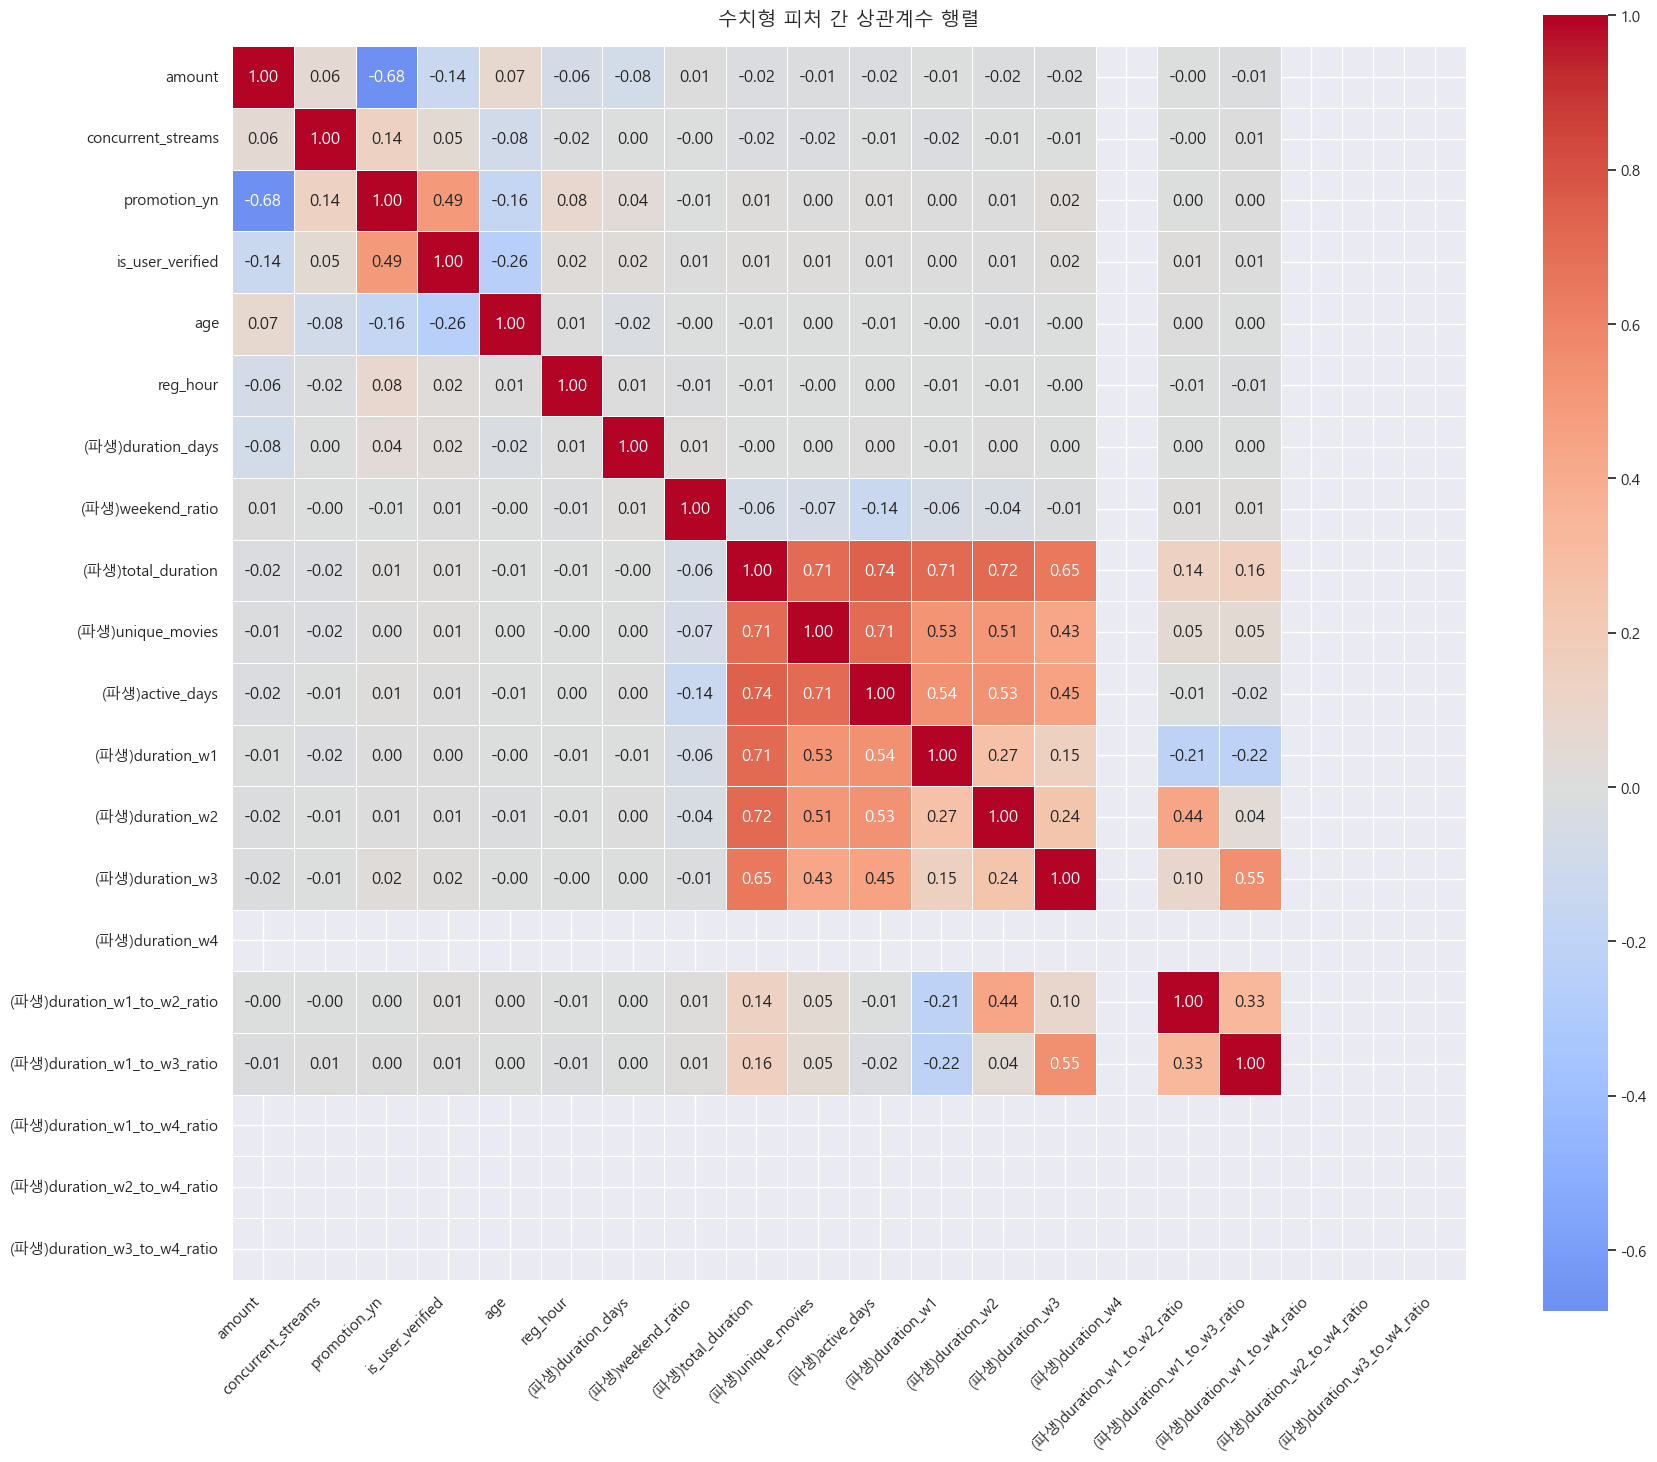


[ |상관계수| >= 0.7 인 쌍 ]
              col1              col2     corr
(파생)total_duration   (파생)active_days 0.738671
(파생)total_duration   (파생)duration_w2 0.715307
(파생)total_duration   (파생)duration_w1 0.714469
(파생)total_duration (파생)unique_movies 0.709485
 (파생)unique_movies   (파생)active_days 0.707066


In [15]:
df = pd.read_excel(r"final_merged_user(단칼)_v1.xlsx")

# 다중공선성 검토 대상 수치형 컬럼
# repurchase, is_churn_prevented는 타깃 변수이므로 제외
# gender, product_cd는 범주형이므로 제외
numeric_cols = [
    'amount',
    'concurrent_streams',
    'promotion_yn',
    'is_user_verified',
    'age',
    'reg_hour',
    '(파생)duration_days',
    '(파생)weekend_ratio',
    '(파생)total_duration',
    '(파생)unique_movies',
    '(파생)active_days',
    '(파생)duration_w1',
    '(파생)duration_w2',
    '(파생)duration_w3',
    '(파생)duration_w4',
    '(파생)duration_w1_to_w2_ratio',
    '(파생)duration_w1_to_w3_ratio',
    '(파생)duration_w1_to_w4_ratio',
    '(파생)duration_w2_to_w4_ratio',
    '(파생)duration_w3_to_w4_ratio',
]

df_numeric = df[numeric_cols]

# 상관계수 행렬 계산
corr_matrix = df_numeric.corr()

# 히트맵 시각화
fig, ax = plt.subplots(figsize=(18, 15))

sns.heatmap(
    corr_matrix,
    annot=True,          # 셀 안에 수치 표시
    fmt='.2f',           # 소수점 2자리
    cmap='coolwarm',     # 양의 상관: 빨강, 음의 상관: 파랑
    center=0,            # 0 기준으로 색상 분기
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('수치형 피처 간 상관계수 행렬', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 0.7 이상 상관쌍 출력
print("\n[ |상관계수| >= 0.7 인 쌍 ]")
high_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ['col1', 'col2', 'corr']
high_corr = high_corr[high_corr['corr'].abs() >= 0.7].sort_values('corr', ascending=False)
print(high_corr.to_string(index=False) if not high_corr.empty else "해당 없음")

> 수치형 피처 간 다중공선성 검토

대상 컬럼 (total 20개):

**원본**
1. `amount`
2. `concurrent_streams`
3. `promotion_yn`
4. `is_user_verified`
5. `age`
6. `reg_hour`

**파생**
7. `(파생)duration_days`
8. `(파생)weekend_ratio`
9. `(파생)total_duration`
10. `(파생)unique_movies`
11. `(파생)active_days`
12. `(파생)duration_w1`
13. `(파생)duration_w2`
14. `(파생)duration_w3`
15. `(파생)duration_w4`
16. `(파생)duration_w1_to_w2_ratio`
17. `(파생)duration_w1_to_w3_ratio`
18. `(파생)duration_w1_to_w4_ratio`
19. `(파생)duration_w2_to_w4_ratio`
20. `(파생)duration_w3_to_w4_ratio`

---

타깃 변수인 `repurchase`와 `is_churn_prevented`는 검토 대상에서 제외함.  
범주형 컬럼인 `gender`, `product_cd`는 수치형 변환 없이는 상관계수 산출이 불가능하여 제외함.

> 주요 상관관계 쌍 (실행 후 업데이트 필요)

**amount와 promotion_yn: -0.68**

두 컬럼 사이의 상관계수가 -0.68로 높게 나타남.  
`promotion_yn`은 100원딜 적용 여부만을 나타내는 이진 변수이고,  
`amount`는 100원딜을 포함한 모든 결제 금액을 담는 수치형 변수.  
100원딜 적용자의 amount가 낮게 찍히면서 생긴 자연스러운 관계이므로 둘 다 유지.

**promotion_yn과 is_user_verified: 0.50**

본인인증이 프로모션 수혜의 전제조건이라는 도메인 규칙에 의해 발생한 상관관계.  
0.7 미만이므로 당장 제거할 수준은 아님. 모델 학습 후 피처 중요도 재검토 필요.

**주간 시청량 파생변수 간 상관**

`duration_w1` ~ `duration_w4`는 `total_duration`의 분해이므로 높은 상관 가능성 있음.  
`|corr| >= 0.7` 쌍이 확인되면 주간 비율 변수 (`duration_w1_to_w2_ratio` 등)로 대체 검토.

> 결론

0.7을 초과하는 쌍이 코드 하단 출력에서 확인됨. 해당 없으면 다중공선성 문제 없음으로 판단.  
범주형 컬럼들이 인코딩되어 모델에 투입된 이후 수치형 피처들과의 관계는 별도 검토 필요.